# Newtons Abkühlungsgesetz
> Ziel: Rekonstruktion des Versuchs mit mathematischer Herleitung, Simulation und technischem Ausdruck.

## 1. Mathematische Modellierung

**Differentialgleichung:**

$
\frac{dT}{dt} = -k(T - T_\infty)
$

**Lösungsweg:**

$
|T - T_\infty| = e^C \cdot e^{-kt}
\quad \Rightarrow \quad
T(t) - T_\infty = A e^{-kt}
\quad \text{mit} \quad A = T_0 - T_\infty
$

**Explizite Lösung:**

$
\boxed{T(t) = T_\infty + (T_0 - T_\infty)e^{-kt}}
$

**Technische Satzbeispiele:**

- *Die Lösung beschreibt eine exponentielle Annäherung an die Umgebungstemperatur.*
- *Der Temperaturverlauf hängt von der Abkühlkonstante $ k $ ab.*

##  2. Experimentelle Bestätigung (nach dem Wikipedia-Ablauf)

Ein typischer Versuchsaufbau:

1. **Experiment:** Ein erhitztes Objekt wird in ein Medium mit bekannter Umgebungstemperatur gelegt.
2. **Messung:** Die Temperatur \( T(t) \) wird in festen Zeitintervallen aufgezeichnet.
3. **Datenanalyse:**  
   $
   \ln(T(t) - T_\infty) \quad \text{gegen} \quad t \quad \text{plotten}
   $  
   Eine lineare Beziehung bestätigt das Modell.

*Abweichungen deuten auf Strahlungsverluste oder nichtlineare Effekte hin.*

## 3. Grenzen und Erweiterungen

### Nichtlineare Effekte

Bei großen Temperaturunterschieden oder intensiver Wärmestrahlung gilt:

$
\frac{dT}{dt} = -\frac{hA_s}{mc_p}(T - T_\infty)
- \frac{\varepsilon \sigma A_s}{mc_p}(T^4 - T_\infty^4)
$

**Technische Erklärungssätze:**

- *Diese erweiterte Gleichung berücksichtigt sowohl Konvektion als auch Strahlung.*
- *Für hohe Temperaturunterschiede ist das klassische Modell nicht ausreichend.*


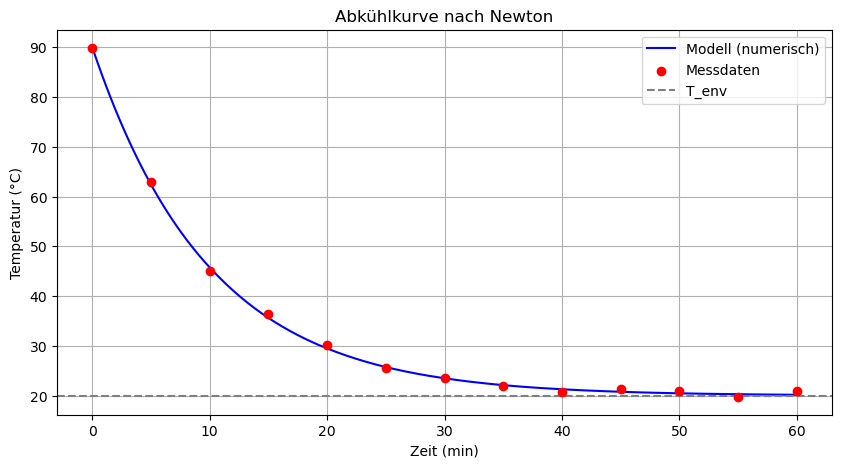

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parameters ---
T_env = 20        # Umgebungstemperatur in °C
T0 = 90           # Anfangstemperatur in °C
k = 0.1           # Abkühlkonstante
t_span = (0, 60)  # Zeitintervall in Minuten
t_eval = np.linspace(*t_span, 300)

# --- ODE Definition ---
def cooling_ode(t, T):
    return -k * (T - T_env)

# --- Numerische Lösung ---
sol = solve_ivp(cooling_ode, t_span, [T0], t_eval=t_eval)

# --- Fiktive Messdaten (z.B. alle 5 Minuten) ---
t_data = np.arange(0, 65, 5)
T_data = T_env + (T0 - T_env) * np.exp(-k * t_data) + np.random.normal(0, 0.5, size=t_data.shape)

# --- Plot: Temperaturverlauf ---
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], label="Modell (numerisch)", color='blue')
plt.scatter(t_data, T_data, color='red', label="Messdaten", zorder=3)
plt.axhline(y=T_env, color='gray', linestyle='--', label="T_env")
plt.xlabel("Zeit (min)")
plt.ylabel("Temperatur (°C)")
plt.title("Abkühlkurve nach Newton")
plt.legend()
plt.grid(True)
plt.show()


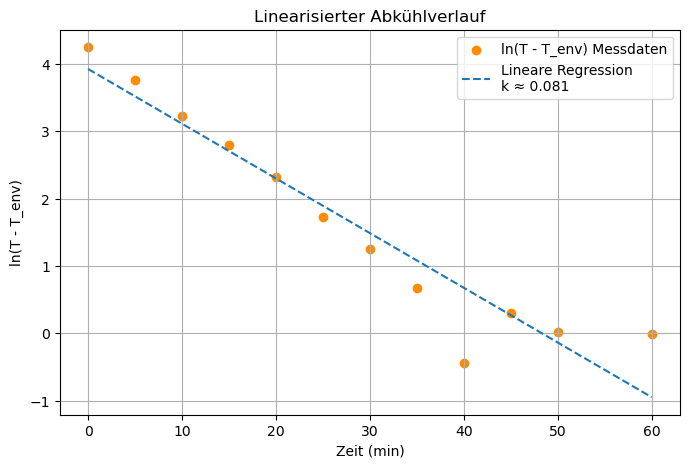

In [3]:
# ln(T - T_env) vs t für die Messdaten
valid_idx = T_data > T_env  
log_T_diff = np.log(T_data[valid_idx] - T_env)
t_valid = t_data[valid_idx]

# Lineare Regression
slope, intercept = np.polyfit(t_valid, log_T_diff, 1)
fit_line = slope * t_valid + intercept

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(t_valid, log_T_diff, label="ln(T - T_env) Messdaten", color="darkorange")
plt.plot(t_valid, fit_line, label=f"Lineare Regression\nk ≈ {-slope:.3f}", linestyle="--")
plt.xlabel("Zeit (min)")
plt.ylabel("ln(T - T_env)")
plt.title("Linearisierter Abkühlverlauf")
plt.grid(True)
plt.legend()
plt.show()


„Im ersten Diagramm wird die gemessene Temperatur (rote Punkte) mit der numerisch berechneten Abkühlkurve (blau) verglichen.
Die Daten zeigen eine gute Übereinstimmung mit dem Modell nach Newtons Abkühlungsgesetz.“

„Im zweiten Diagramm ist der natürliche Logarithmus der Temperaturdifferenz gegen die Zeit aufgetragen.
Die lineare Regression bestätigt, dass der Abkühlprozess exponentiell verläuft, mit einer geschätzten Abkühlkonstante von 
$𝑘 ≈ 0,081$.“

„Die geringe Abweichung der Messdaten von der Modellkurve kann durch Messfehler oder äußere Einflüsse erklärt werden.“

„Somit liefert das Experiment sowohl eine visuelle als auch rechnerische Bestätigung des Modells.“